**Feature Selection**

In [5]:
#Feature Selection & Preparation for Clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("student_performance_dataset.csv")  # adjust path if needed
print("Shape:", df.shape)
df.head()


Shape: (3000, 21)


,student_id,age,gender,program,prior_gpa,total_logins,avg_session_duration,time_spent_on_materials,num_forum_posts,num_forum_replies,...,quiz_attempts,quiz_scores_avg,assignment_scores_avg,final_exam_score,text_feature_1,text_feature_2,text_feature_3,text_feature_4,text_feature_5,student_performance
0,S0001,24,Male,Diploma,2.25,129,44.43,32.47,21,10,...,3,93.55,67.14,56.16,0.808,0.204,0.594,0.216,0.734,Fail
1,S0002,37,Female,BSc,2.12,106,26.31,9.99,16,8,...,3,83.12,91.33,52.73,0.421,0.823,0.949,0.555,0.901,Fail
2,S0003,32,Male,Diploma,2.61,125,40.68,35.72,13,8,...,2,50.27,86.04,31.85,0.034,0.463,0.503,0.416,0.315,Pass
3,S0004,28,Other,BSc,2.32,132,12.61,49.29,15,5,...,3,52.41,76.74,94.96,0.723,0.553,0.082,0.951,0.888,Pass
4,S0005,25,Female,Diploma,2.35,118,14.96,45.75,17,13,...,6,88.86,42.76,91.00,0.353,0.246,0.628,0.043,0.496,Pass


In [9]:
#Selecting  relevant numerical features for clustering.
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Drop any ID-like columns
numeric_df = numeric_df.loc[:, ~numeric_df.columns.str.contains('id|ID|Index', case=False)]

# Select top 4 features by variance
variances = numeric_df.var().sort_values(ascending=False)
selected_features = list(variances.index[:4])
print("Selected Features:", selected_features)

# Handle missing values
X = numeric_df[selected_features].fillna(numeric_df[selected_features].mean())


Selected Features: ['final_exam_score', 'quiz_scores_avg', 'assignment_scores_avg', 'avg_session_duration']


In [7]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,0.909663,-0.432227
1,-0.241900,1.192334
2,-1.496841,0.008081
3,-0.616370,1.402622
4,0.691622,-0.216367


**Clustering Algorithm - K-Means Clustering**

In [11]:
# K-Means Clustering with k = 3

from sklearn.cluster import KMeans

# Fix number of clusters
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)



In [12]:
# Add cluster centers (for optional use)
centroids = kmeans.cluster_centers_

print(f"✅ Model fitted with k = {k}")
df.head()

✅ Model fitted with k = 3


,student_id,age,gender,program,prior_gpa,total_logins,avg_session_duration,time_spent_on_materials,num_forum_posts,num_forum_replies,...,quiz_scores_avg,assignment_scores_avg,final_exam_score,text_feature_1,text_feature_2,text_feature_3,text_feature_4,text_feature_5,student_performance,Cluster
0,S0001,24,Male,Diploma,2.25,129,44.43,32.47,21,10,...,93.55,67.14,56.16,0.808,0.204,0.594,0.216,0.734,Fail,0
1,S0002,37,Female,BSc,2.12,106,26.31,9.99,16,8,...,83.12,91.33,52.73,0.421,0.823,0.949,0.555,0.901,Fail,2
2,S0003,32,Male,Diploma,2.61,125,40.68,35.72,13,8,...,50.27,86.04,31.85,0.034,0.463,0.503,0.416,0.315,Pass,1
3,S0004,28,Other,BSc,2.32,132,12.61,49.29,15,5,...,52.41,76.74,94.96,0.723,0.553,0.082,0.951,0.888,Pass,2
4,S0005,25,Female,Diploma,2.35,118,14.96,45.75,17,13,...,88.86,42.76,91.00,0.353,0.246,0.628,0.043,0.496,Pass,2


**Add Cluster Labels to Dataset**

In [13]:
# Cluster Labels & Summarize

# Mean values of each feature per cluster
cluster_summary = df.groupby('Cluster')[selected_features].mean().round(2)
display(cluster_summary)


,final_exam_score,quiz_scores_avg,assignment_scores_avg,avg_session_duration
Cluster,,,,
0,78.11,71.82,70.26,49.04
1,44.22,66.84,68.06,35.00
2,77.36,72.47,71.89,21.87


In [14]:
# Cluster size distribution
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\nCluster Distribution:")
print(cluster_counts)


Cluster Distribution:
Cluster
0     957
1    1125
2     918
Name: count, dtype: int64


**Visualizations using Matplotlib**

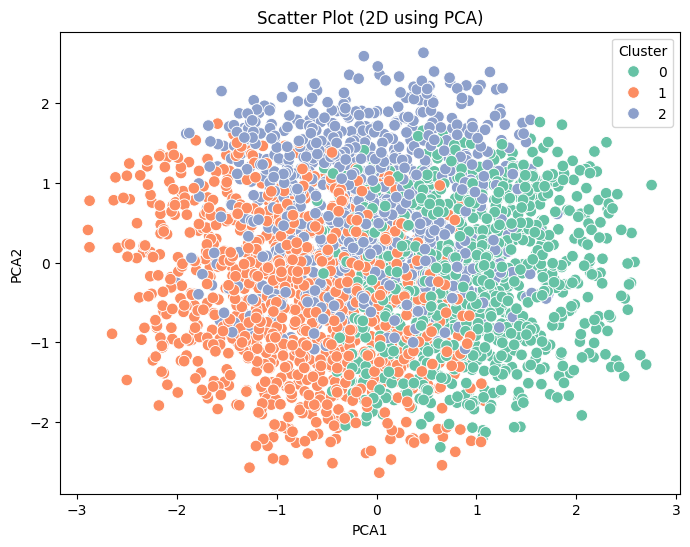

In [16]:
# Visualizations

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[selected_features])

# PCA for 2D view
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)
df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2', s=70)
plt.title('Scatter Plot (2D using PCA)')
plt.show()

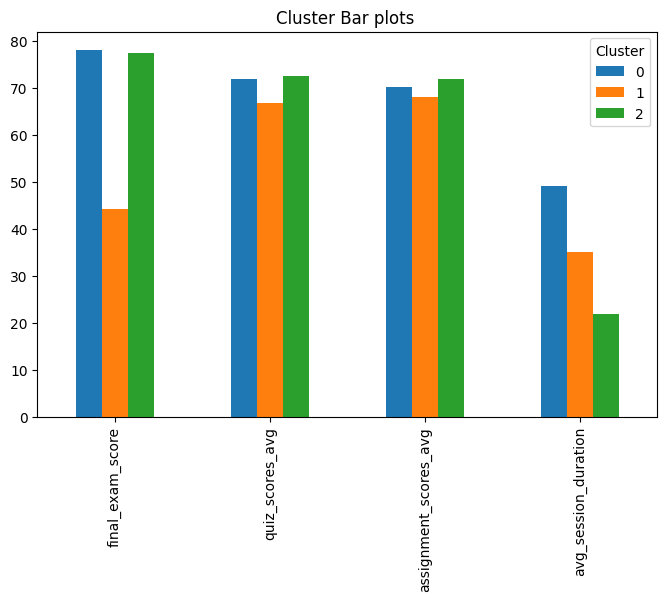

In [17]:
# Bar plot (mean values)
cluster_summary = df.groupby('Cluster')[selected_features].mean().reset_index()
cluster_summary.set_index('Cluster').T.plot(kind='bar', figsize=(8,5))
plt.title('Cluster Bar plots ')
plt.show()

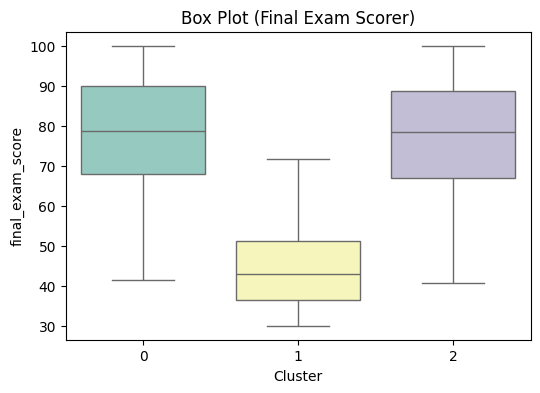

In [18]:
# Box plot (final_exam_score across clusters)
plt.figure(figsize=(6,4))
sns.boxplot(x='Cluster', y='final_exam_score', data=df, hue='Cluster', palette='Set3', legend=False)
plt.title('Box Plot (Final Exam Scorer)')
plt.show()

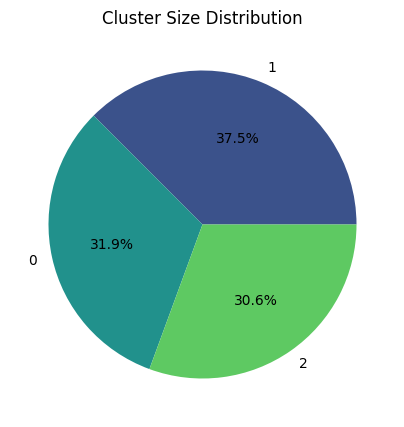

In [19]:
# Pie chart (cluster size)
cluster_counts = df['Cluster'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(cluster_counts)))
plt.title('Cluster Size Distribution')
plt.show()

**Interpretation & Insights**

In [21]:
# Interpretation & Insights

import pandas as pd
from IPython.display import display, Markdown

print("Cluster Interpretation:\n")

# Display each cluster's feature summary as a table
for i in range(k):
    display(Markdown(f"### Cluster {i} "))
    display(cluster_summary[cluster_summary['Cluster'] == i].style.background_gradient(cmap='Blues'))
    print("-" * 50)


Cluster Interpretation:



### Cluster 0 

,Cluster,final_exam_score,quiz_scores_avg,assignment_scores_avg,avg_session_duration
0,0,78.109770,71.824911,70.256353,49.044316


--------------------------------------------------


### Cluster 1 

,Cluster,final_exam_score,quiz_scores_avg,assignment_scores_avg,avg_session_duration
1,1,44.218267,66.841813,68.059298,35.003413


--------------------------------------------------


### Cluster 2 

,Cluster,final_exam_score,quiz_scores_avg,assignment_scores_avg,avg_session_duration
2,2,77.358399,72.467527,71.889717,21.868987


--------------------------------------------------
